In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from itertools import combinations
import seaborn as sns

In [11]:
# Load clustered regions and annotated bedpe, and filter to final analysis samples
final_analysis_samples = pd.read_csv('../../../SV_sample_data/data/final_analysis_samples.csv')
clustered_regions = pd.read_csv('../results/all_samples_clustering_regions.txt', sep='\t')
clustered_regions = clustered_regions[clustered_regions['sample'].isin(final_analysis_samples['tumor_normal_pair'])]
annotated_bedpe = pd.read_csv('../results/all_samples_annotated_bedpe.txt', sep='\t')
annotated_bedpe = annotated_bedpe[annotated_bedpe['sample'].isin(final_analysis_samples['tumor_normal_pair'])]
print("Total samples: ", annotated_bedpe['sample'].nunique())

Total samples:  205


Total breakpoints: 106498
Clustered breakpoints: 33692
Non-clustered breakpoints: 72806


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_72535/3974633055.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_bp['window'] = (c_bp['pos'] // window_size).astype(int)
/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_72535/3974633055.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  n_bp['window'] = (n_bp['pos'] // window_size).astype(int)
/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_72535/3974633055.py:83: SettingWithCopyWarning: 
A value is trying to be set on


HOTSPOT WINDOW SUMMARY: 
Total windows: 5,976
Windows with breakpoints: 2,936
Windows with clustered breakpoints: 2,143
Windows exported to: ../results/hotspot_windows.csv

Top 10 higher clustered breakpoint windows:
chromosome  window_start_mb  window_end_mb  clustered_breakpoints  total_breakpoints   hotspot_rank
        17             15.0           16.0                     29                 69 top_5%_density
        17             13.0           14.0                     24                 53 top_5%_density
        17             14.0           15.0                     23                 50 top_5%_density
        19             29.0           30.0                     22                 67 top_5%_density
        17             17.0           18.0                     21                 61 top_5%_density
         8            129.0          130.0                     20                 49 top_5%_density
        17             16.0           17.0                     20                 

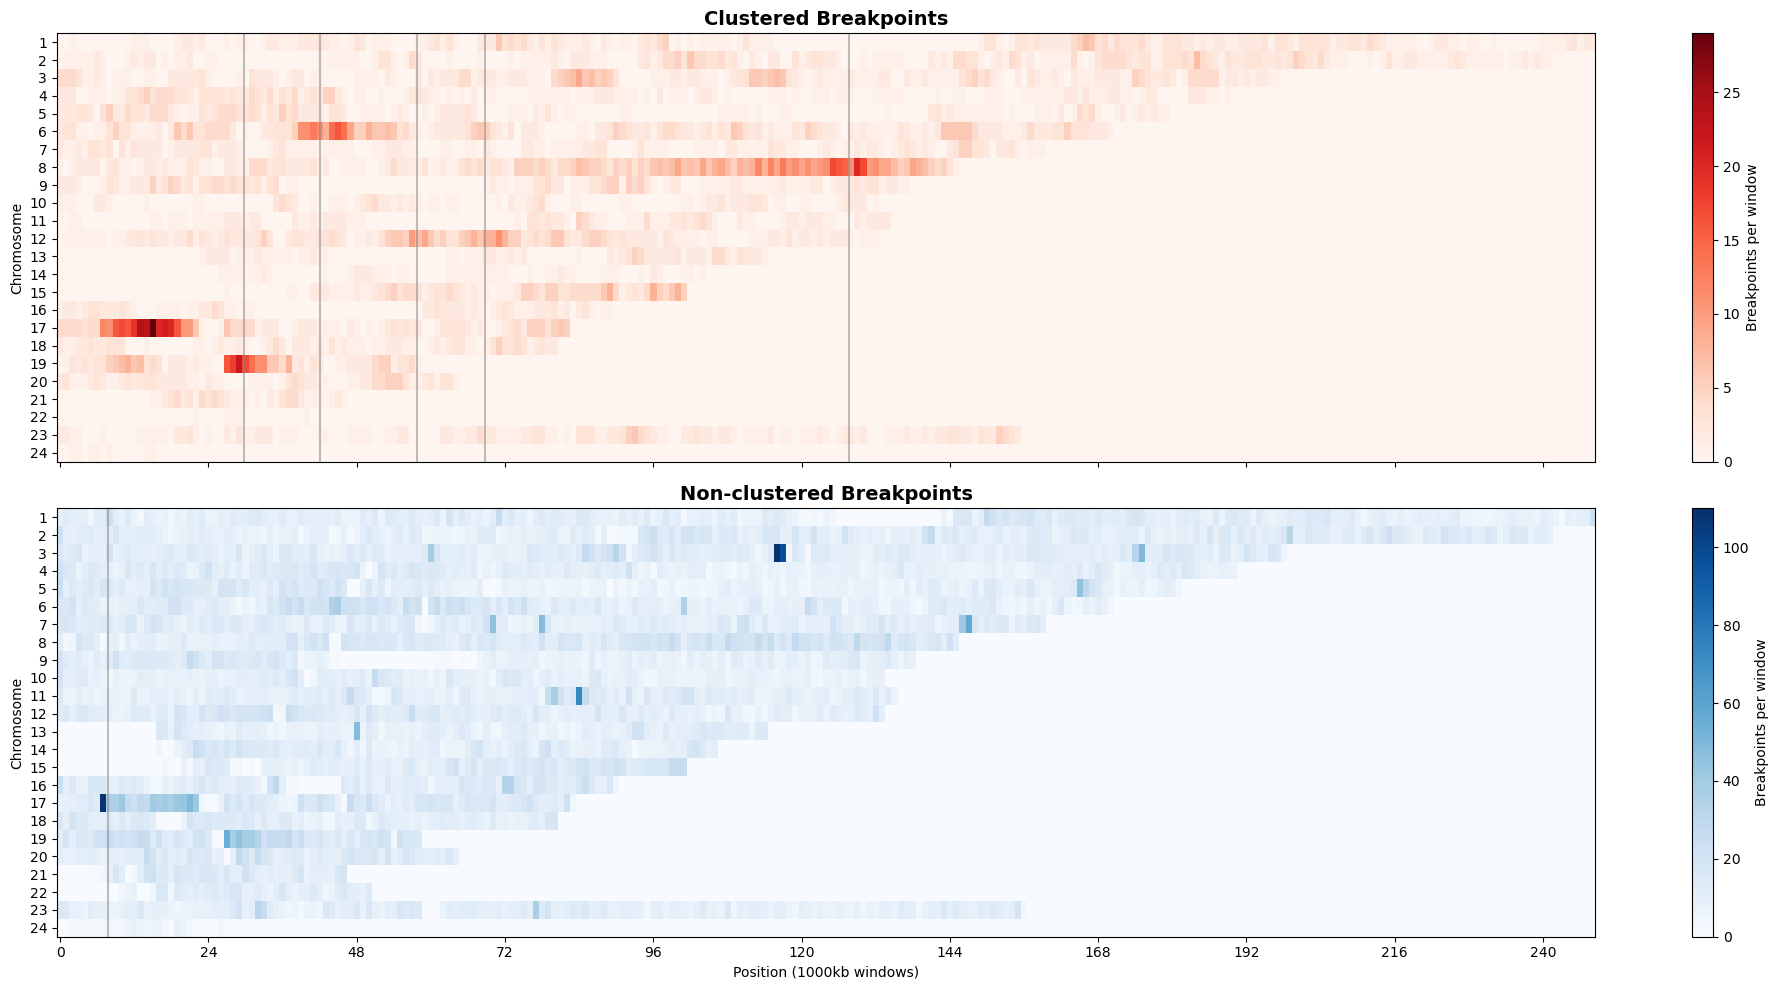

In [13]:
def map_breakpoints_to_clusters(annotated_bedpe, clustering_regions):
    # Annotate all breakpoints as clustered or not whether they are in a clustered region or not

    # Convert chromosome columns to string
    annotated_bedpe['chrom1'] = annotated_bedpe['chrom1'].astype(str)
    annotated_bedpe['chrom2'] = annotated_bedpe['chrom2'].astype(str)
    clustering_regions['chr'] = clustering_regions['chr'].astype(str)
    
    # Extract all breakpoints (both ends of each SV)
    bp1 = annotated_bedpe[['chrom1', 'end1', 'sample']].copy()
    bp1.columns = ['chrom', 'pos', 'sample']
    bp1['breakpoint_id'] = annotated_bedpe.index.astype(str) + '_1'
    bp1['sv_id'] = annotated_bedpe.index
    bp2 = annotated_bedpe[['chrom2', 'end2', 'sample']].copy()
    bp2.columns = ['chrom', 'pos', 'sample']
    bp2['breakpoint_id'] = annotated_bedpe.index.astype(str) + '_2'
    bp2['sv_id'] = annotated_bedpe.index
    
    all_breakpoints = pd.concat([bp1, bp2], ignore_index=True)
    
    # Initialize all breakpoints as non-clustered
    all_breakpoints['is_clustered_validated'] = False
    
    # For each clustering region, find breakpoints within it
    for _, region in clustering_regions.iterrows():
        sample = region['sample']
        chrom = region['chr']
        start = region['start.bp']
        end = region['end.bp']
        
        # Find breakpoints in this region for this sample
        mask = (
            (all_breakpoints['sample'] == sample) &
            (all_breakpoints['chrom'] == chrom) &
            (all_breakpoints['pos'] >= start) &
            (all_breakpoints['pos'] <= end)
        )
        
        all_breakpoints.loc[mask, 'is_clustered_validated'] = True
    
    return all_breakpoints

def create_clustering_heatmap(annotated_bedpe, clustering_regions, ch_sizes, window_size=500000):

    # Map breakpoints to clusters
    all_breakpoints = map_breakpoints_to_clusters(annotated_bedpe, clustering_regions)
    
    chromosomes = [str(i) for i in range(1, 25)]
    ch_sizes["chromosome"] = chromosomes
    ch_sizes = ch_sizes[["chromosome", "size"]]

    # Separate clustered and non-clustered breakpoints
    clustered_bp = all_breakpoints[all_breakpoints['is_clustered_validated'] == True]
    non_clustered_bp = all_breakpoints[all_breakpoints['is_clustered_validated'] == False]
    
    print(f"Total breakpoints: {len(all_breakpoints)}")
    print(f"Clustered breakpoints: {len(clustered_bp)}")
    print(f"Non-clustered breakpoints: {len(non_clustered_bp)}")
    
    # Calculate density matrices
    clustered_matrix = []
    non_clustered_matrix = []
    chromosomes_with_data = []
    
    for chrom in chromosomes:
        c_bp = clustered_bp[clustered_bp['chrom'] == chrom]
        n_bp = non_clustered_bp[non_clustered_bp['chrom'] == chrom]
        
        if len(c_bp) == 0 and len(n_bp) == 0:
            continue
            
        chromosomes_with_data.append(chrom)
        
        # Find chromosome length
        size = ch_sizes[ch_sizes['chromosome'] == chrom]['size'].values[0]
        
        # Create windows & count unique samples per window (max 1 breakpoint per sample per window)
        windows = np.arange(0, size, window_size)
        c_counts = np.zeros(len(windows))
        n_counts = np.zeros(len(windows))
        
        if len(c_bp) > 0:
            c_bp['window'] = (c_bp['pos'] // window_size).astype(int)
            c_counts_series = c_bp.groupby('window')['sample'].nunique()
            for window_idx, count in c_counts_series.items():
                if window_idx < len(c_counts):
                    c_counts[window_idx] = count
        
        if len(n_bp) > 0:
            n_bp['window'] = (n_bp['pos'] // window_size).astype(int)
            n_counts_series = n_bp.groupby('window')['sample'].nunique()
            for window_idx, count in n_counts_series.items():
                if window_idx < len(n_counts):
                    n_counts[window_idx] = count
        
        clustered_matrix.append(c_counts)
        non_clustered_matrix.append(n_counts)
    
    # Convert to arrays and pad to same length
    max_len = max(len(row) for row in clustered_matrix + non_clustered_matrix)
    clustered_array = np.array([np.pad(row, (0, max_len - len(row))) for row in clustered_matrix])
    non_clustered_array = np.array([np.pad(row, (0, max_len - len(row))) for row in non_clustered_matrix])
    
    return clustered_array, non_clustered_array, chromosomes_with_data, max_len, window_size

def export_window_coordinates_with_ranking(clustered_array, non_clustered_array, chromosomes_with_data, window_size, output_file="../results/hotspot_windows.csv"):
    
    hotspot_data = []
    
    # Extract data for all windows
    for chrom_idx, chrom in enumerate(chromosomes_with_data):
        clustered_counts = clustered_array[chrom_idx]
        non_clustered_counts = non_clustered_array[chrom_idx]
        total_counts = clustered_counts + non_clustered_counts
        
        for window_idx, (clustered_count, non_clustered_count, total_count) in enumerate(
            zip(clustered_counts, non_clustered_counts, total_counts)):
            
            # Calculate window coordinates
            window_start = window_idx * window_size
            window_end = window_start + window_size
            window_center = window_start + window_size // 2
            
            hotspot_data.append({
                'chromosome': chrom,
                'window_start_bp': window_start,
                'window_end_bp': window_end,
                'window_center_bp': window_center,
                'window_start_mb': round(window_start / 1e6, 2),
                'window_end_mb': round(window_end / 1e6, 2),
                'window_center_mb': round(window_center / 1e6, 2),
                'clustered_breakpoints': int(clustered_count),
                'non_clustered_breakpoints': int(non_clustered_count),
                'total_breakpoints': int(total_count),
            })
    
    df = pd.DataFrame(hotspot_data)
    df['hotspot_rank'] = ''
    
    # Filter for windows with at least 1 clustered breakpoint
    significant_windows = df[df['clustered_breakpoints'] >= 1].copy()
    
    if len(significant_windows) > 0:
        # Rank by clustered breakpoint count
        significant_windows_sorted = significant_windows.sort_values('clustered_breakpoints', ascending=False)
        
        # Add labels for top densities
        top_10_percent = max(1, len(significant_windows_sorted) // 10)
        top_5_percent = max(1, len(significant_windows_sorted) // 20)
        
        top_5_indices = significant_windows_sorted.head(top_5_percent).index
        top_10_indices = significant_windows_sorted.head(top_10_percent).index
        df.loc[top_5_indices, 'hotspot_rank'] = 'top_5%_density'
        top_10_only_indices = top_10_indices[~top_10_indices.isin(top_5_indices)]
        df.loc[top_10_only_indices, 'hotspot_rank'] = 'top_10%_density'
    
    # Sort by chromosome and position
    chromosome_order = {str(i): i for i in range(1, 25)}
    df['chrom_order'] = df['chromosome'].map(chromosome_order)
    df = df.sort_values(['chrom_order', 'window_start_bp']).drop('chrom_order', axis=1)
    
    # Export to CSV
    df.to_csv(output_file, index=False)
    
    # Print summary
    print(f"\nHOTSPOT WINDOW SUMMARY: ")
    print(f"Total windows: {len(df):,}")
    print(f"Windows with breakpoints: {len(df[df['total_breakpoints'] > 0]):,}")
    print(f"Windows with clustered breakpoints: {len(df[df['clustered_breakpoints'] > 0]):,}")
    print(f"Windows exported to: {output_file}")
    
    top_hotspots = df[df['hotspot_rank'].str.contains('top_', na=False)]
    if len(top_hotspots) > 0:
        print("\nTop 10 higher clustered breakpoint windows:")
        display_cols = ['chromosome', 'window_start_mb', 'window_end_mb', 'clustered_breakpoints', 'total_breakpoints', 'hotspot_rank']
        print(top_hotspots.nlargest(10, 'clustered_breakpoints')[display_cols].to_string(index=False))
    
    return df

def plot_clustering_heatmaps(clustered_array, non_clustered_array, chromosomes_with_data, max_len, window_size, clustering_regions=None):

    fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)
    
    # Define genes and their coordinates
    clustered_genes = [
        {'name': 'CCND3', 'chrom': '6', 'start': 41934934, 'end': 42050357},
        {'name': 'MYC', 'chrom': '8', 'start': 127735434, 'end': 127742951},
        {'name': 'CDK4', 'chrom': '12', 'start': 57747722, 'end': 57756013},
        {'name': 'CCNE1', 'chrom': '19', 'start': 29811471, 'end': 29824313},
        {'name': 'MDM2', 'chrom': '12', 'start': 68808172, 'end': 68850686},
    ]
    
    non_clustered_genes = [
        {'name': 'TP53', 'chrom': '17', 'start': 7668421, 'end': 7687490},
    ]
    
    # Plot 1: Clustered breakpoints heatmap
    im1 = axes[0].imshow(clustered_array, cmap='Reds', aspect='auto', interpolation='nearest')
    axes[0].set_title('Clustered Breakpoints', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Chromosome')
    axes[0].set_yticks(range(len(chromosomes_with_data)))
    axes[0].set_yticklabels(chromosomes_with_data)
    axes[0].grid(False)
    plt.colorbar(im1, ax=axes[0], label='Breakpoints per window')
    
    # Add gene markers to clustered plot
    for gene in clustered_genes:
        if gene['chrom'] in chromosomes_with_data:
            gene_center = (gene['start'] + gene['end']) / 2
            x_pos = gene_center / window_size
            axes[0].axvline(x=x_pos, color='gray', linestyle='-', linewidth=1.5, alpha=0.5)
    
    # Plot 2: Non-clustered breakpoints heatmap  
    im2 = axes[1].imshow(non_clustered_array, cmap='Blues', aspect='auto', interpolation='nearest')
    axes[1].set_title('Non-clustered Breakpoints', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Chromosome')
    axes[1].set_xlabel(f'Position ({window_size/1000:.0f}kb windows)')
    axes[1].set_yticks(range(len(chromosomes_with_data)))
    axes[1].set_yticklabels(chromosomes_with_data)
    axes[1].grid(False)
    plt.colorbar(im2, ax=axes[1], label='Breakpoints per window')
    
    # Add gene markers to non-clustered plot
    for gene in non_clustered_genes:
        if gene['chrom'] in chromosomes_with_data:
            gene_center = (gene['start'] + gene['end']) / 2
            x_pos = gene_center / window_size
            axes[1].axvline(x=x_pos, color='gray', linestyle='-', linewidth=1.5, alpha=0.5)
    
    # Add x-axis labels
    for ax in axes:
        x_ticks = np.arange(0, max_len, max(1, max_len//10))
        x_labels = [f"{int(x * window_size / 1e6)}" for x in x_ticks]
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_labels)
    
    plt.tight_layout()
    return fig

# Main analysis function
def analyze_and_export_hotspots(annotated_bedpe, clustering_regions, ch_sizes, window_size=1000000):

    # 1. Map breakpoints and create density arrays
    clustered_array, non_clustered_array, chromosomes_with_data, max_len, window_size = create_clustering_heatmap(annotated_bedpe, clustering_regions, ch_sizes, window_size)
    # 2. Export window coordinates with ranking
    hotspot_df = export_window_coordinates_with_ranking(clustered_array, non_clustered_array, chromosomes_with_data, window_size)
    # 3.Create visualization
    fig = plot_clustering_heatmaps(clustered_array, non_clustered_array, chromosomes_with_data, max_len, window_size, clustering_regions)
    
    return fig, hotspot_df

ch_sizes = pd.read_csv("../../../SRB_analysis/data/hg38_ref_files/hg38_chr.bed", sep='\t')
ch_sizes = ch_sizes[['chromEnd']]
ch_sizes = ch_sizes.reset_index(drop=True)
ch_sizes.columns = ['size']
fig, hotspot_df = analyze_and_export_hotspots(annotated_bedpe, clustered_regions, ch_sizes)
fig.savefig('../results/clustering_hotspots.png', dpi=300, bbox_inches='tight')

In [5]:
# Create clustered SV hotspot file
events = {
    "CCND3" : {"chrom":6, "start":39000000, "end":55000000},
    "MYC" : {"chrom":8, "start":99000000, "end":137000000}, 
    "CDK4-MDM2" : {"chrom":12, "start":53000000, "end":75000000},
    "CCNE1" : {"chrom":19, "start":27000000, "end":34000000},
    "TP53" : {"chrom":17, "start":7000000, "end":22000000}
}

# events dict already defined
events_df = (
    pd.DataFrame.from_dict(events, orient='index')
      .reset_index()
      .rename(columns={'index': 'event'})
)

events_df.to_csv('../results/hotspot_event_definitions.csv', index=False)
events_df.head(5)

,event,chrom,start,end
0,CCND3,6,39000000,55000000
1,MYC,8,99000000,137000000
2,CDK4-MDM2,12,53000000,75000000
3,CCNE1,19,27000000,34000000
4,TP53,17,7000000,22000000
